# Figure 2: Compute ocean heat uptake efficiency ($\kappa$) and plot with $\alpha$

Last updated Sept 1 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
# find files that start with a certain string
def find_files(directory,start_str):
    import os
    files = [f for f in os.listdir(directory) if f.startswith(start_str)]

    # Handle only the first matching file
    if files:
        matching_file = files[-1]
        #print(f"Found file: {matching_file}")
        return matching_file
    else:
        print(f"No file found {directory, start_str}.")
        return None

In [4]:
def get_experiment_names(model):
    if model == 'FLOR':
        extension = 'tigercpu_intelmpi_18_576PE'
        exps = ['p6p0sol_CTL1860',
                'p4p0sol_CTL1860',
                'p2p0sol_CTL1860', 
                'p1p0sol_CTL1860',
                #'CTL1860_newdiag',
                'm1p0sol_CTL1860', 
                'm2p0sol_CTL1860',
                'm4p0sol_CTL1860',
                'm6p0sol_CTL1860',]
        modelstr = 'FLOR'

    if model == 'CM2.1p1':
        extension = 'tigercpu_intelmpi_18_80PE'
        exps = ['CTL1860_p6pctSolar', 
                'CTL1860_p4pctSolar',
                'CTL1860_p2pctSolar',
                'CTL1860_p1pctSolar', 
                #'CTL1860',
                'CTL1860_m1pctSolar',
                'CTL1860_m2pctSolar',
                'CTL1860_m4pctSolar',
                'CTL1860_m6pctSolar',
                ]
        modelstr = 'CM2.1'
    return exps, extension, modelstr

# Compute OHC and Ts anomaly from CTRL rolling climatology (50yr window, updated every 5 yrs)

In [6]:
def anomaly_from_moving_climatology(da, CTRL, window=50*12, step=5*12):
    
    anoms = []
    
    # Loop through the data in step-sized chunks
    for start in range(0, da.sizes['time'], step):
        end = start + step
        da_chunk = da.isel(time=slice(start, end))
        
        # Define corresponding climatology window in CTRL
        # (shift the window so it's aligned in time with da_chunk)
        t0 = da_chunk.time.values[0]
        
        # Find index in CTRL closest to t0
        idx0 = int(np.argmin(np.abs(CTRL.time.values - t0)))
        
        # Take 50-year slice of CTRL centered around idx0
        c_start = max(0, idx0 - window//2)
        c_end = min(CTRL.sizes['time'], c_start + window)
        CTRL_subset = CTRL.isel(time=slice(c_start, c_end))
        
        # Compute monthly climatology
        CTRL_clim = CTRL_subset.groupby("time.month").mean("time")
        
        # Compute anomaly for this chunk
        anom_chunk = da_chunk.groupby("time.month") - CTRL_clim
        anoms.append(anom_chunk)
    
    # Concatenate back together
    anom = xr.concat(anoms, dim="time")
    return anom


# Compute OHC and Ts anomalies from CTRL

In [25]:
def compute_ohc_Ts_anomaly(model, experiment, 
                 dirin_ohc = '/tigress/mvchung/ANALYSIS/Solar_NEW/processed_data/total_ocean_heat/',
                 dirin_Ts = '/tigress/mvchung/ANALYSIS/Solar_NEW/global_mean/'):

    # import monthly global total ocean heat content [J * 1e25]
    file = find_files(dirin_ohc,f'total_ocean_heat_ts_{model}_{experiment}')
    print(file)
    ohc = xr.open_dataarray(f'{dirin_ohc}{file}')
    ohc = ohc.squeeze()
    ohc = ohc*1e25 # convert to joules because model output was divided by 1e25

    # load CTRL ohc data
    if model == 'FLOR':
        CTRL_string = 'CTL1860_newdiag'
    elif model == 'CM2.1p1':
        CTRL_string = 'CTL1860'
    file = find_files(dirin_ohc,f'total_ocean_heat_ts_{model}_{CTRL_string}.')
    print(file)
    ohc_CTRL = xr.open_dataarray(f'{dirin_ohc}{file}')
    ohc_CTRL = ohc_CTRL.squeeze()
    ohc_CTRL = ohc_CTRL*1e25
    
    # get anomaly from 50-year moving climatology updated every 5 years
    ohc = anomaly_from_moving_climatology(ohc, ohc_CTRL, window=50*12, step=5*12) # get anomaly
    
    # get annual average and divide by seconds in a year to get OHU or N(t) [J/s]
    ohc_annual = ohc.groupby('time.year').mean('time')
    
    # import surface temperature (Ts) data
    file = find_files(dirin_Ts,f't_ref_{model}_{experiment}_{extension}')
    Ts = xr.open_dataarray(f'{dirin_Ts}{file}')
    
    # import CTRL
    file = find_files(dirin_Ts,f't_ref_{model}_{CTRL_string}_{extension}')
    Ts_CTRL = xr.open_dataarray(f'{dirin_Ts}{file}')
    # get anomaly from CTRL
    Ts = anomaly_from_moving_climatology(Ts, Ts_CTRL, window=50*12, step=5*12) # get anomaly
    # get annual average
    Ts_annual = Ts.groupby('time.year').mean('time')

    # save data
    dirout = './processed_data/for_OHUE'
    ohc_annual.to_netcdf(f'{dirout}/ohc_annual_anom_50yr_{model}_{experiment}.nc')
    Ts_annual.to_netcdf(f'{dirout}/t_ref_annual_anom_50yr_{model}_{experiment}.nc')
    
    return ohc_annual, Ts_annual

In [27]:
# compute OHC and Ts anomalies from CTRL, takes a few minutes

modelnames = ['CM2.1p1','FLOR']
modelstr = ['CM2.1','FLOR']

for ii in range(np.size(modelnames)):

    all_kappas = []  # store DataArrays
    
    # get the names of the experiments
    exps, extension, modelstr = get_experiment_names(modelnames[ii])

    for iexp in range(np.size(exps)):
        ohc_annual, Ts_annual = compute_ohc_Ts_anomaly(modelnames[ii], exps[iexp])
        

total_ocean_heat_ts_CM2.1p1_CTL1860_p6pctSolar.0101-0310.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_p4pctSolar.0101-2000.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_p2pctSolar.0101-1100.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_p1pctSolar.0101-0300.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_m1pctSolar.0101-0300.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_m2pctSolar.0101-1100.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_m4pctSolar.0101-2000.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_m6pctSolar.0101-1293.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_FLOR_p6p0sol_CTL1860.0101-1000.nc
total_ocean_heat_ts_FLOR_CTL1860_newdiag.0101-2200.nc
total_ocean_heat_ts_

# compute OHU efficiency $\kappa$

In [31]:
def compute_kappa(model, experiment, label, window_len = 150,
                 dirin_ohc = '/tigress/mvchung/ANALYSIS/Solar_NEW/processed_data/for_OHUE/',
                 dirin_Ts = '/tigress/mvchung/ANALYSIS/Solar_NEW/processed_data/for_OHUE/'):

    # import monthly global total ocean heat content [J * 1e25]
    file = find_files(dirin_ohc,f'ohc_annual_anom_50yr_{model}_{experiment}.nc')
    ohc_annual = xr.open_dataarray(f'{dirin_ohc}{file}')
    ohc_annual = ohc_annual.squeeze()
    #ohc_annual = ohc_annual*1e25 # convert to joules because model output was divided by 1e25
    
    seconds_per_year = 365*24*3600 # want to actually compute seconds based on the time dimension
    earth_area = 4 * np.pi * (6.371e6)**2  # m²
    
    # import surface temperature (Ts) data
    file = find_files(dirin_Ts,f't_ref_annual_anom_50yr_{model}_{experiment}.nc')
    Ts_annual = xr.open_dataarray(f'{dirin_Ts}{file}')
    
    # compute OHU efficiency
    years_array = ohc_annual['year'].values
    
    kappa_list = []
    mid_years = []
    
    for start in range(0, len(years_array) - window_len + 1):
        end = start + window_len
        ohu_window = ohc_annual.isel(year=slice(start, end))
        Ts_window = Ts_annual.isel(year=slice(start, end))
        
        # Linear regression slope: κ = dN/dTs
        slope, intercept = np.polyfit(Ts_window.values, ohu_window.values, 1)
        kappa_list.append(slope / (window_len * seconds_per_year * earth_area))  # W/m²/K 
        mid_years.append(years_array[start + window_len//2])
    
    # Store in xarray
    kappa = xr.DataArray(
        kappa_list,
        coords={'year': mid_years},
        dims='year',
        name=f'OHUeff_{label}',
        attrs={
            'units': 'W m$^{-2}$ K$^{-1}$',  # W per m² per Kelvin
            'long_name': 'OHU Efficiency'
        }
    )

    return kappa

# Compute and plot kappa for all the models and experiments

In [33]:
# load and plot all the experiments

plt.style.use('../func/paper.mplstyle')

modelnames = ['FLOR','CM2.1p1']
modelstr = ['FLOR','CM2.1']

labels = [
          '+6%',
          '+4%',
          '+2%',
          '+1%',
          #'CTRL',
          '-1%',
          '-2%',
          '-4%',
          '-6%',
        ]
colors = [
         'darkred',
         'red',
         'orange',
         'gold',
        #'grey',
         'cyan',
         'dodgerblue',
         'blue',
         'darkblue',
        ]

In [34]:
# compute OHU efficiency for all the experiments and models 
# takes a few minutes (computing anomalies from CTRL, could do this separately)

for ii in range(np.size(modelnames)):

    all_kappas = []  # store DataArrays
    
    # get the names of the experiments
    exps, extension, modelstr = get_experiment_names(modelnames[ii])

    for iexp in range(np.size(exps)):
        kappa = compute_kappa(modelnames[ii], exps[iexp], label=labels[iexp], window_len=150)
        
        all_kappas.append(kappa)

    if modelnames[ii]=='FLOR':
        # Combine into one Dataset
        kappa_ds_FLOR = xr.merge(all_kappas) 
    else:
        kappa_ds_CM21 = xr.merge(all_kappas) 

Text(0.5, 0.98, 'OHU efficiency ($\\kappa$)')

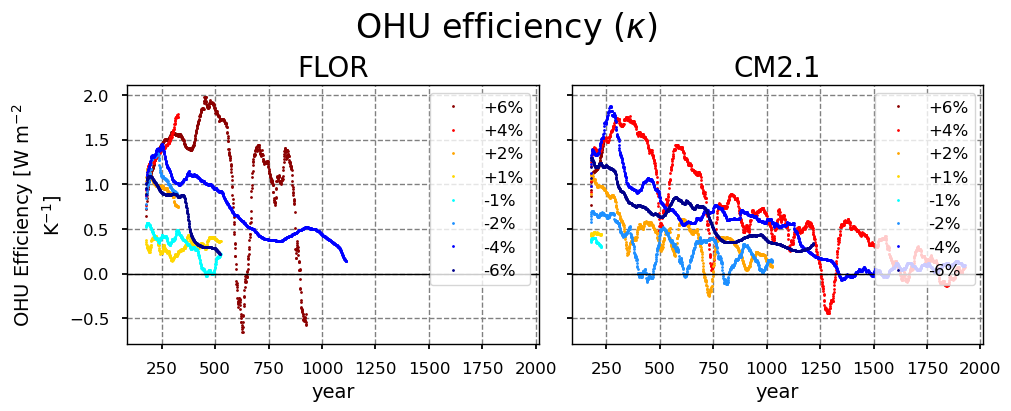

In [35]:
# plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

# Left panel = FLOR variables
for ivar, var_name in enumerate(kappa_ds_FLOR.data_vars):
    kappa_ds_FLOR[var_name].plot(
        ax=ax[0],
        color=colors[ivar],
        label=labels[ivar],
        zorder=1,
        linestyle='None',
        marker='.',
        markersize=2
    )

# Right panel = CM2.1 variables
for ivar, var_name in enumerate(kappa_ds_CM21.data_vars):
    kappa_ds_CM21[var_name].plot(
        ax=ax[1],
        color=colors[ivar],
        label=labels[ivar],
        zorder=1,
        linestyle='None',
        marker='.',
        markersize=2
    )

for axis in ax.flatten():
    axis.legend()
    axis.grid('--')
    axis.axhline(0, color='k', linewidth=1)

ax[0].set_title('FLOR')
ax[1].set_title('CM2.1')
ax[1].set_ylabel('')
#ax[0].set_ylim(-5,5)

fig.suptitle('OHU efficiency ($\kappa$)')


In [36]:
kappa_ds_FLOR

<xarray.Dataset> Size: 68kB
Dimensions:     (year: 938)
Coordinates:
  * year        (year) int64 8kB 176 177 178 179 180 ... 1110 1111 1112 1113
Data variables:
    OHUeff_+6%  (year) float64 8kB 0.643 0.7178 0.772 0.8129 ... nan nan nan nan
    OHUeff_+4%  (year) float64 8kB 0.7627 0.8695 0.9346 0.9869 ... nan nan nan
    OHUeff_+2%  (year) float64 8kB 0.8995 1.039 1.083 1.114 ... nan nan nan nan
    OHUeff_+1%  (year) float64 8kB 0.3713 0.3514 0.33 0.319 ... nan nan nan nan
    OHUeff_-1%  (year) float64 8kB 0.5179 0.5275 0.5466 0.5511 ... nan nan nan
    OHUeff_-2%  (year) float64 8kB 0.7344 0.7843 0.8427 0.8895 ... nan nan nan
    OHUeff_-4%  (year) float64 8kB 0.8788 0.9517 1.017 ... 0.1418 0.1384 0.1351
    OHUeff_-6%  (year) float64 8kB 0.8879 0.9531 1.0 1.027 ... nan nan nan nan
Attributes:
    units:      W m$^{-2}$ K$^{-1}$
    long_name:  OHU Efficiency

# Plot all together including the sum of $\alpha$ and $\kappa$

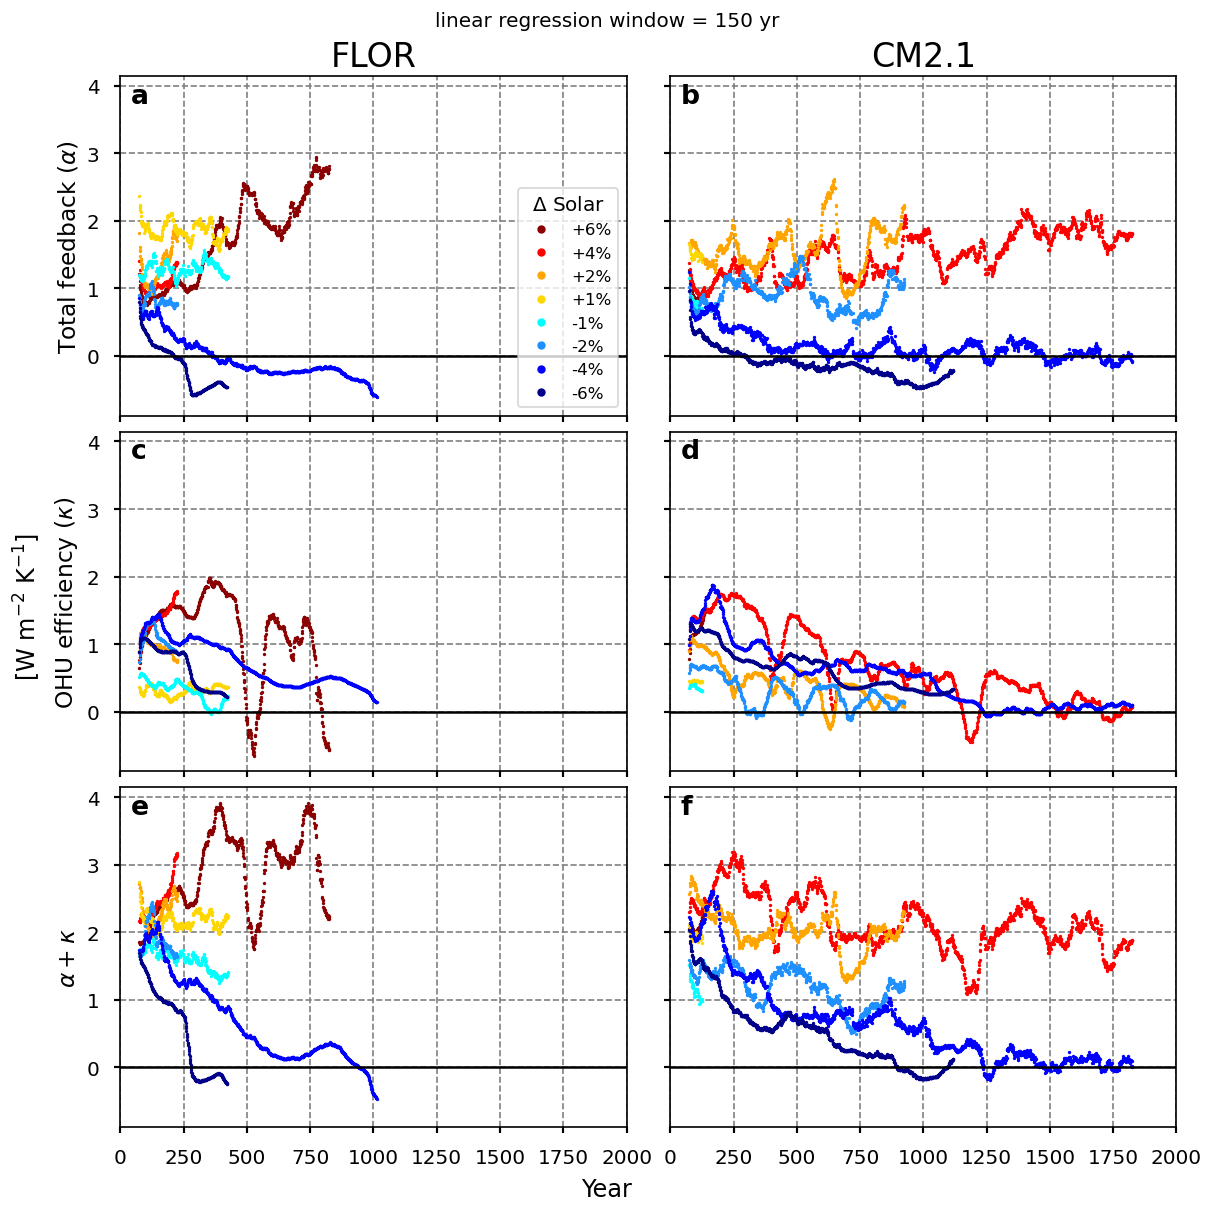

In [61]:
ref = '50yr'
window_size = 150

fig, ax = plt.subplots(3,2,figsize=(10,10), dpi=120, sharex=True, sharey=True)

models = ['FLOR','CM2.1p1']

for imodel in range(np.size(models)):

    for iexp in range(np.size(labels)):
    
        exps, extension, modelstr = get_experiment_names(models[imodel])
        exp = labels[iexp]

        total_feedback = xr.open_dataarray(f'./feedbacks_MVC/total_feedback_cloud/total_feedback_{models[imodel]}_{exp}solar_ref_{ref}_window_{window_size}.nc')
        alpha = -total_feedback
        # plot total climate feedback -- constant rh decomposition
        # 150-year window, shifting reference period (50 years, every 5 years)        
        # centered on window (x-axis)
        ax[0,imodel].plot(alpha.year-101,
                          alpha, 
                          linestyle='None', marker = '.', markersize=2,
                      label=f'{exp}',
                        color=colors[iexp])
        ax[0,imodel].set_title(models[imodel])

        # plot OHU efficiency
        if models[imodel]=='FLOR':
            kappa = kappa_ds_FLOR
        else:
            kappa = kappa_ds_CM21
        ax[1,imodel].plot(kappa.year-101, kappa[f'OHUeff_{exp}'], 
                          linestyle='None', marker = '.', markersize=2,label=f'{exp}',
                        color=colors[iexp])
        
        # plot lamba + kappa
        kappa_cleaned = kappa[f'OHUeff_{exp}'].where(~xr.ufuncs.isnan(kappa[f'OHUeff_{exp}']), drop=True)
        ax[2,imodel].plot(alpha.year-101, 
                          kappa_cleaned + alpha, 
                          linestyle='None', marker = '.', markersize=2,label=f'{exp}',
                        color=colors[iexp])
        

legend = ax[0,0].legend(title=r'$\Delta$ Solar',fontsize=10, markerscale=4,loc='lower right') # makes the legend markers bigger
    

for axis in ax.flatten():
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.axhline(0,color='k',linewidth=1.5)
    axis.grid('--')
    axis.set_xlim(0,2000)


# Add subplot labels 'a', 'b', 'c', 'd' in upper left corners
subplot_labels = ['a', 'b', 'c', 'd', 'e', 'f']
for i, axis in enumerate(ax.flatten()):
    axis.text(0.02, 0.98, subplot_labels[i],
              transform=axis.transAxes,
              fontsize=16,
              fontweight='bold',
              va='top', ha='left')

ax[0,1].set_title('CM2.1')
fig.supxlabel('Year')
ax[0,0].set_ylabel(r'Total feedback ($\alpha$)')
ax[1,0].set_ylabel(r'OHU efficiency ($\kappa$)')
ax[2,0].set_ylabel(r'$\alpha + \kappa$')
fig.supylabel('[W m$^{-2}$ K$^{-1}$]')
fig.suptitle(f'linear regression window = {window_size} yr',fontsize=12)

plt.savefig('Figure2.pdf',dpi=300)

# Closer look at experiments with negative $\kappa$

Looks like the warming experiments +6% and +4% both have occasional large drops in OHUE.

These are times where the surface temperature is cools despite increasing OHC for centuries. 

Would need to look closer to understand why.

### FLOR +6% Solar

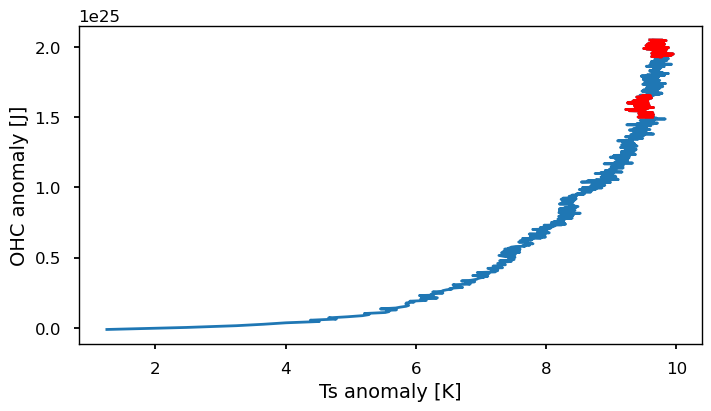

In [59]:
# FLOR +6% Solar
ohc = xr.open_dataarray('./processed_data/for_OHUE/ohc_annual_anom_50yr_FLOR_p6p0sol_CTL1860.nc')
Ts = xr.open_dataarray('./processed_data/for_OHUE/t_ref_annual_anom_50yr_FLOR_p6p0sol_CTL1860.nc')
plt.plot(Ts, ohc)
plt.ylabel('OHC anomaly [J]')
plt.xlabel('Ts anomaly [K]')

plt.plot(Ts.isel(year=slice(500,600)), ohc.isel(year=slice(500,600)), color='r')
plt.plot(Ts.isel(year=slice(-100, None)), ohc.isel(year=slice(-100, None)), color='r')

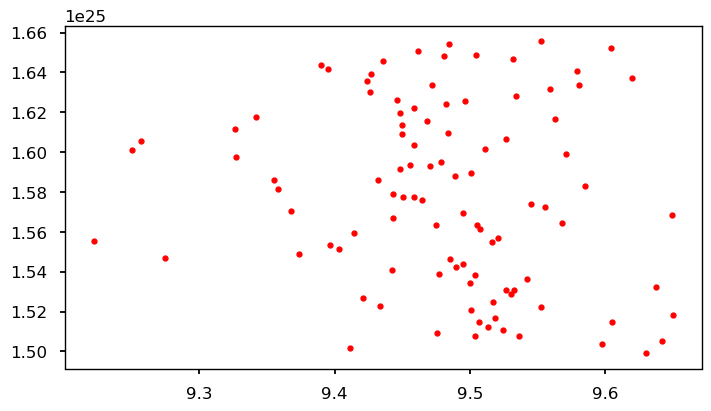

In [60]:
plt.plot(Ts.isel(year=slice(500,600)), ohc.isel(year=slice(500,600)), color='r', linestyle='None',marker='.')

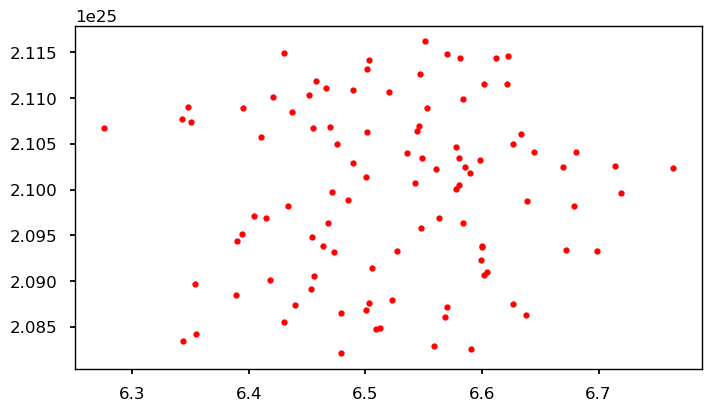

In [58]:
plt.plot(Ts.isel(year=slice(-100, None)), ohc.isel(year=slice(-100, None)), color='r', linestyle='None',marker='.')

### CM2.1 +4% Solar

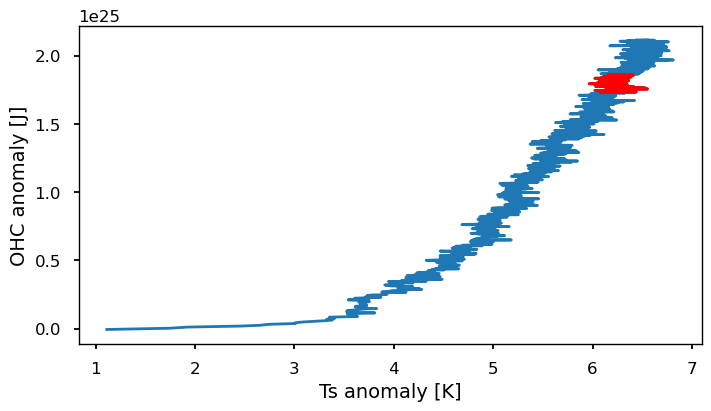

In [53]:
# CM2.1 +4% Solar
ohc = xr.open_dataarray('./processed_data/for_OHUE/ohc_annual_anom_50yr_CM2.1p1_CTL1860_p4pctSolar.nc')
Ts = xr.open_dataarray('./processed_data/for_OHUE/t_ref_annual_anom_50yr_CM2.1p1_CTL1860_p4pctSolar.nc')
plt.plot(Ts, ohc)
plt.ylabel('OHC anomaly [J]')
plt.xlabel('Ts anomaly [K]')

plt.plot(Ts.isel(year=slice(1100,1300)), ohc.isel(year=slice(1100,1300)), color='r')

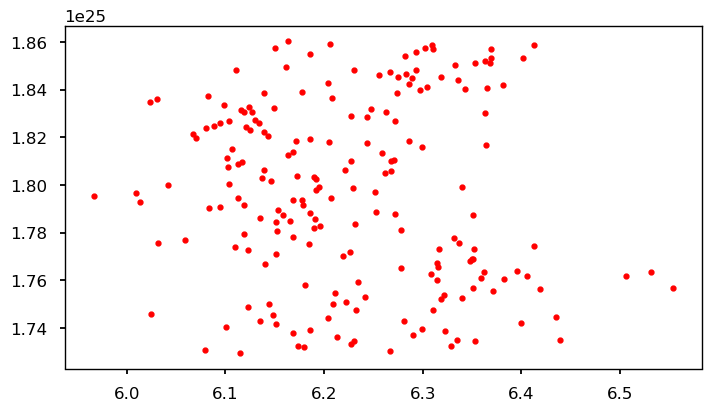

In [55]:
plt.plot(Ts.isel(year=slice(1100,1300)), ohc.isel(year=slice(1100,1300)), color='r', linestyle='None', marker='.')